In [1]:
import os
import sys
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

sys.path.insert(0, os.path.abspath("../../src"))
from pipeline import run_etl, DOMINIOS
from modeling import seed, scoring, get_confusion_matrix, cv_repeated_kfold, cv_kfold, graficar_curvas_roc_multiclase, print_scores,nested_cross_validation_multi
df_tabla_0_imp, df_tabla_1_imp, df_mean, df_median = run_etl("../../.env")

Descargando datos desde GitHub...
Hojas cargadas: 125
Tabla 0 (escolaridad baja) : 36
Tabla 1 (escolaridad alta) : 81
No determinadas            : 8
df_tabla_0 crudo : (36, 32)
df_tabla_1 crudo : (81, 29)

 Imputando nulos...
--- Perfil nulos Tabla 0 ---
                                         nulos  %_nulos dtype  n_unicos
fluidez_verbal_semantica                    23    63.89   str         4
matrices                                    12    33.33   str         4
imagenes_sobrepuestas                       11    30.56   str         3
stroop_interferencia                         9    25.00   str         4
material_verbal_complejo                     6    16.67   str         3
denominacion                                 5    13.89   str         1
stroop_palabra                               4    11.11   str         4
stroop_color                                 4    11.11   str         4
atencion_sostenida_visual                    4    11.11   str         4
evocacion_diferida       

In [2]:
#Features para el modelo
DOMINIOS_COGNITIVOS = list(DOMINIOS.keys())
features = [col for col in df_mean.columns if col != "dc"]

X_mean = df_mean[features]
y_mean = pd.to_numeric(df_mean["dc"], errors='coerce').fillna(-1).astype(int)

X_median = df_median[features]
y_median = pd.to_numeric(df_median["dc"], errors='coerce').fillna(-1).astype(int)

In [3]:
#Cargar modelos
model_package_lr = joblib.load('../../models/modelo_logistic_regression_diagnostico.joblib')
model_package_rf = joblib.load('../../models/modelo_random_forest_diagnostico.joblib')
model_package_svm_lineal = joblib.load('../../models/modelo_svm_lineal_diagnostico.joblib')
model_package_svm_rbf = joblib.load('../../models/modelo_svm_rbf_diagnostico.joblib')

In [4]:
models = {
    'Logistic Regression': model_package_lr,
    'Random Forest': model_package_rf,
    'SVM Lineal': model_package_svm_lineal,
    'SVM RBF': model_package_svm_rbf
}

In [5]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline


def permutation_importance_cv(
    model,
    X,
    y,
    cv,
    scoring='f1_macro',
    n_repeats=30,
    random_state=seed,
    model_name=None
):
    """
    Calcula la importancia por permutación sobre cada partición
    de validación cruzada y genera una gráfica con el nombre del modelo en el título.
    """

#Model name
    if model_name is None:
        if isinstance(model, Pipeline):
            # Si es un Pipeline, toma el nombre de la clase del último estimador
            model_name = type(model.steps[-1][1]).__name__
        else:
            # Si es un modelo directo, toma su nombre de clase
            model_name = type(model).__name__

    importancias_folds = []

    #Validación cruzada
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):

        # Separación entre entrenamiento y validación
        X_train = X.iloc[train_idx] if hasattr(X, 'iloc') else X[train_idx]
        X_val = X.iloc[val_idx] if hasattr(X, 'iloc') else X[val_idx]

        y_train = y.iloc[train_idx] if hasattr(y, 'iloc') else y[train_idx]
        y_val = y.iloc[val_idx] if hasattr(y, 'iloc') else y[val_idx]

        # copia del modelo para no reescribirlo
        modelo_fold = clone(model)

        # se entrena unicamente con los datos de entrenamiento
        modelo_fold.fit(X_train, y_train)

        # Caculo del permutation importance
        resultado = permutation_importance(
            modelo_fold,
            X_val,
            y_val,
            scoring=scoring,
            n_repeats=n_repeats,
            random_state=random_state,
            n_jobs=-1
        )

        importancias_folds.append(resultado.importances_mean)

    # matriz de importancias por fold
    importancias_folds = np.array(importancias_folds)

    # Promedio y Desviación Estándar
    importancia_media = np.mean(importancias_folds, axis=0)
    importancia_std = np.std(importancias_folds, axis=0)

    # dataset final
    nombres_variables = [col.replace('_', ' ').capitalize() for col in X.columns]
    
    df_importancia = pd.DataFrame({
        'Variable': nombres_variables,
        'Importancia_Media': importancia_media,
        'Importancia_Std': importancia_std
    }).sort_values(by='Importancia_Media', ascending=False).reset_index(drop=True)

    #Gráficar

    altura_fig = max(6, len(df_importancia) * 0.4)
    fig, ax = plt.subplots(figsize=(10, altura_fig))

    posiciones = np.arange(len(df_importancia))

    norm = plt.Normalize(
        df_importancia['Importancia_Media'].min(),
        df_importancia['Importancia_Media'].max()
    )

    colores = plt.cm.viridis(norm(df_importancia['Importancia_Media']))

    ax.barh(
        posiciones,
        df_importancia['Importancia_Media'],
        xerr=df_importancia['Importancia_Std'],
        capsize=4,
        color=colores,
        ecolor='black',
        alpha=0.85
    )

    ax.set_yticks(posiciones)
    ax.set_yticklabels(df_importancia['Variable'], fontsize=10)

    # Ordenar por importancia media
    ax.invert_yaxis()

    # Etiquetas de los ejes
    metric_label = scoring.replace('_', ' ').upper() if isinstance(scoring, str) else 'Métrica'
    ax.set_xlabel(f'Disminución promedio en {metric_label}', fontsize=11, labelpad=10)
    ax.set_ylabel('Variable', fontsize=11)
    
    ax.set_title(f'Importancia de las variables ({model_name})', fontweight='bold', fontsize=13)

    # Línea vertical de referencia en 0
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    
    max_reach = (df_importancia['Importancia_Media'] + df_importancia['Importancia_Std']).max()
    min_reach = (df_importancia['Importancia_Media'] - df_importancia['Importancia_Std']).min()

    rango = max_reach - min(0, min_reach)
    offset = rango * 0.02 if rango > 0 else 0.005

    for i, (valor, desviacion) in enumerate(zip(df_importancia['Importancia_Media'], df_importancia['Importancia_Std'])):
        if valor >= 0:
            pos_x = valor + desviacion + offset
            ha_align = 'left'
        else:
            pos_x = valor - desviacion - offset
            ha_align = 'right'

        ax.text(
            pos_x,
            i,
            f'{valor:.4f} ± {desviacion:.4f}',
            va='center',
            ha=ha_align,
            fontsize=8.5,
            fontweight='bold'
        )

    lim_max = max_reach + (rango * 0.25) if max_reach > 0 else 0.05
    lim_min = min_reach - (rango * 0.25) if min_reach < 0 else -0.01
    
    ax.set_xlim(lim_min, lim_max)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

    return df_importancia, fig

In [6]:
from sklearn.model_selection import RepeatedStratifiedKFold

cv_externo = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=seed
)

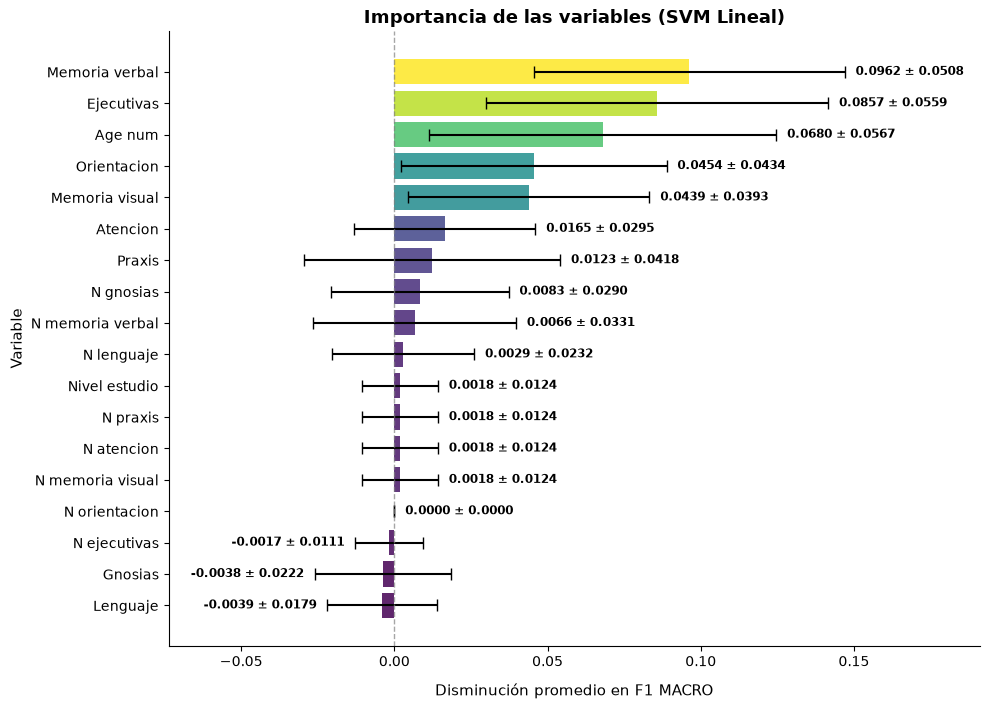

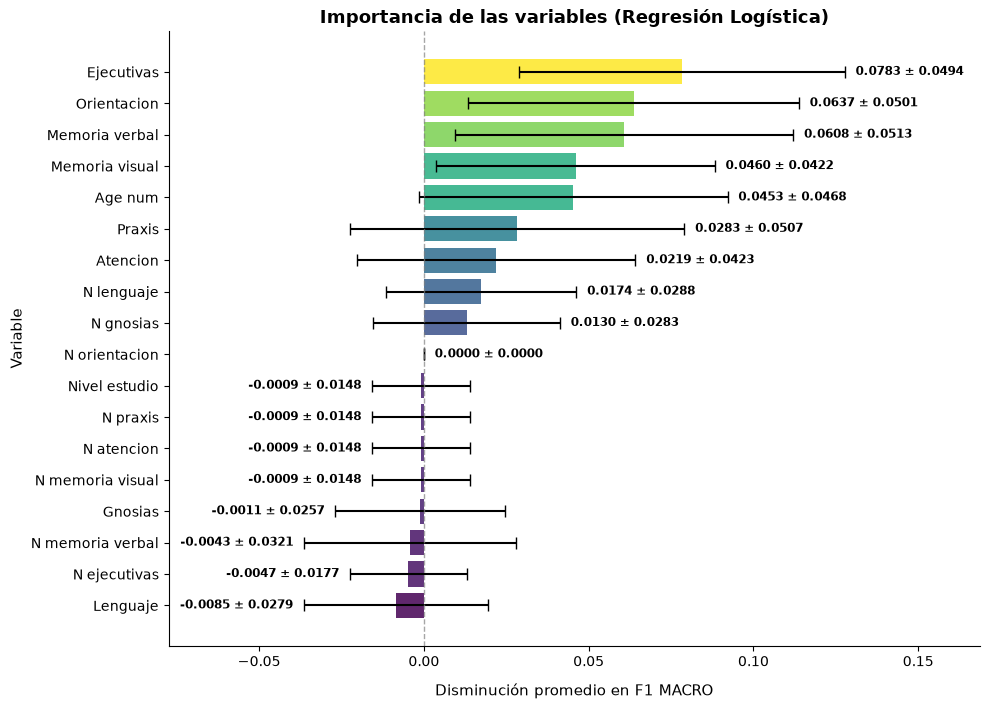

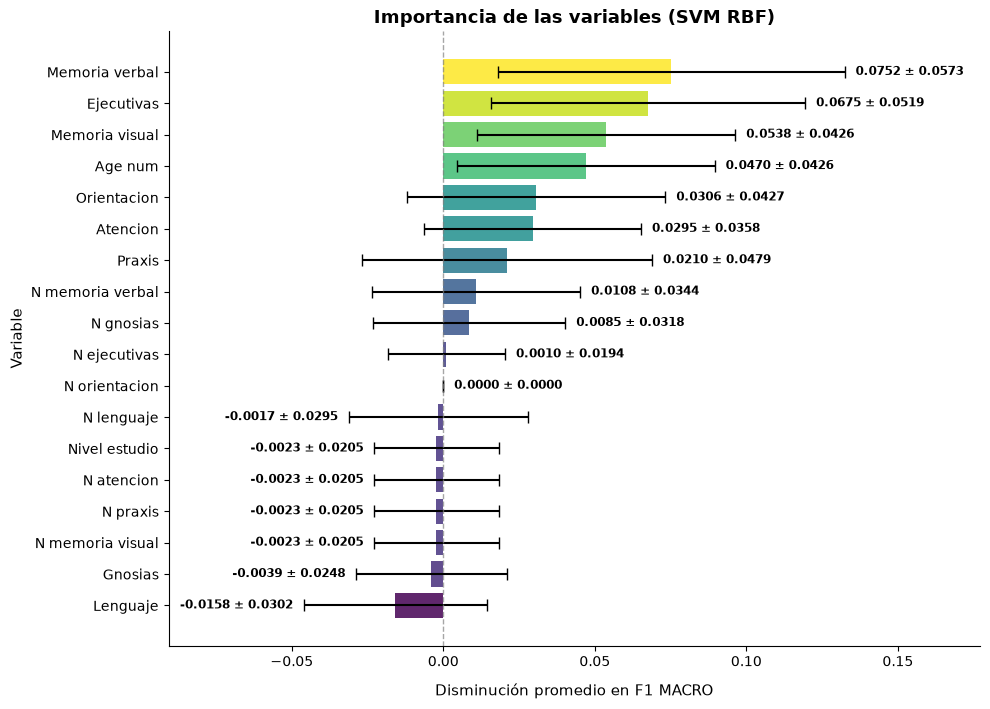

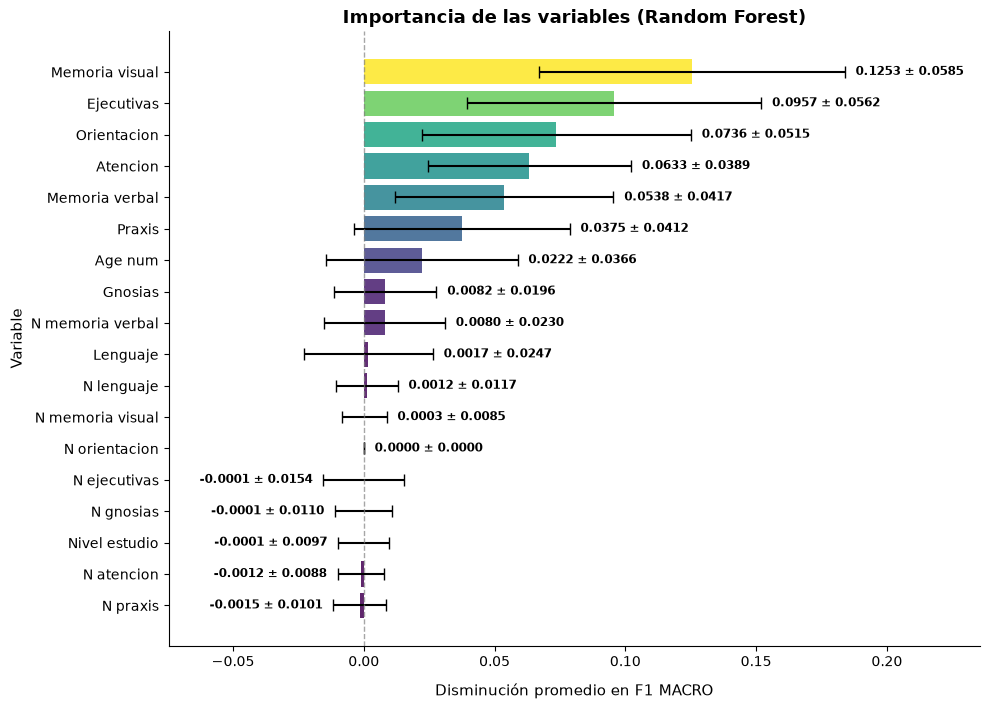

(            Variable  Importancia_Media  Importancia_Std
 0     Memoria visual           0.125344         0.058545
 1         Ejecutivas           0.095748         0.056216
 2        Orientacion           0.073578         0.051495
 3           Atencion           0.063335         0.038867
 4     Memoria verbal           0.053767         0.041676
 5             Praxis           0.037549         0.041153
 6            Age num           0.022170         0.036605
 7            Gnosias           0.008179         0.019605
 8   N memoria verbal           0.007979         0.023049
 9           Lenguaje           0.001728         0.024669
 10        N lenguaje           0.001193         0.011747
 11  N memoria visual           0.000261         0.008454
 12     N orientacion           0.000000         0.000000
 13      N ejecutivas          -0.000071         0.015365
 14         N gnosias          -0.000085         0.010969
 15     Nivel estudio          -0.000112         0.009727
 16        N a

In [7]:
permutation_importance_cv(
    model=models['SVM Lineal'],
    X=X_mean,
    y=y_mean,
    cv=cv_externo,
    scoring='f1_macro',
    n_repeats=30,
    random_state=seed,
    model_name='SVM Lineal' 
)
permutation_importance_cv(
    model=models['Logistic Regression'],
    X=X_mean,
    y=y_mean,
    cv=cv_externo,
    scoring='f1_macro',
    n_repeats=30,
    random_state=seed,
    model_name= 'Regresión Logística'
)
permutation_importance_cv(
    model=models['SVM RBF'],
    X=X_mean,
    y=y_mean,
    cv=cv_externo,
    scoring='f1_macro',
    n_repeats=30,
    random_state=seed,
    model_name='SVM RBF'
)
permutation_importance_cv(
    model=models['Random Forest'],
    X=X_mean,
    y=y_mean,
    cv=cv_externo,
    scoring='f1_macro',
    n_repeats=30,
    random_state=seed,
    model_name='Random Forest'
)

In [ ]:
# # Predicción con un individuo de ejemplo (fila 5 del dataset)
# individuo_ejemplo = X_mean.iloc[[5]]

# # Usamos predict_proba en lugar de predict
# probabilidades = rf_pipeline.predict_proba(individuo_ejemplo)[0]

# print(f"Probabilidad de ser Control Sano {probabilidades[0]*100:.1f}%")
# print(f"Probabilidad de tener DCL {probabilidades[1]*100:.1f}%")
# print(f"Probabilidad de tener Demencia {probabilidades[2]*100:.1f}%")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


def shap_importance_models(model, X, model_name="Modelo"):
    """
    Calcula la importancia mediante SHAP evitando el AttributeError
    en las propiedades read-only de Scikit-Learn / Pipeline.
    """
    nombres_cols = [col.replace('_', ' ').capitalize() for col in X.columns]

    print(f"Calculando SHAP para {model_name}...")

    # Extraer el estimador final si es un Pipeline
    if hasattr(model, 'steps'):
        estimator = model.steps[-1][1]
    else:
        estimator = model


    # CÁLCULO DE SHAP
    # Random Forest
    if isinstance(estimator, RandomForestClassifier):
        X_prep = model.steps[0][1].transform(X) if hasattr(model, 'steps') else X
        X_prep_df = pd.DataFrame(X_prep, columns=nombres_cols)
        explainer = shap.TreeExplainer(estimator)
        shap_vals = explainer.shap_values(X_prep_df)

    #Regresión Logística
    elif isinstance(estimator, LogisticRegression):
        X_prep = model.steps[0][1].transform(X) if hasattr(model, 'steps') else X
        X_prep_df = pd.DataFrame(X_prep, columns=nombres_cols)
        explainer = shap.LinearExplainer(estimator, X_prep_df)
        shap_vals = explainer.shap_values(X_prep_df)

    # SVMs
    else:
        # 1. Creamos una función lambda para desacoplar el objeto Pipeline de SHAP
        # Esto evita que SHAP intente modificar 'feature_names_in_'
        if hasattr(model, "decision_function"):
            fn = lambda data: model.decision_function(pd.DataFrame(data, columns=X.columns))
        elif hasattr(model, "predict_proba"):
            fn = lambda data: model.predict_proba(pd.DataFrame(data, columns=X.columns))[:, 1]
        else:
            fn = lambda data: model.predict(pd.DataFrame(data, columns=X.columns))

        # 2. Convertimos X a numpy para evitar bloqueos de metadata
        X_array = X.values if hasattr(X, 'values') else X
        
        # Muestra de fondo (background)
        idx_sample = np.random.choice(len(X_array), min(30, len(X_array)), replace=False)
        background = X_array[idx_sample]

        explainer = shap.KernelExplainer(fn, background)
        shap_vals = explainer.shap_values(X_array)


    #PROCESAMIENTO DE SHAP VALUES
    if isinstance(shap_vals, list):
        vals = shap_vals[1] if len(shap_vals) > 1 else shap_vals[0]
    elif len(np.shape(shap_vals)) == 3:
        vals = shap_vals[:, :, 1]
    else:
        vals = shap_vals

    abs_vals = np.abs(vals)
    mean_shap = np.mean(abs_vals, axis=0)
    std_shap = np.std(abs_vals, axis=0)

    df_shap = pd.DataFrame({
        'Variable': nombres_cols,
        'Importancia_Media': mean_shap,
        'Importancia_Std': std_shap
    }).sort_values(by='Importancia_Media', ascending=False).reset_index(drop=True)
    
    #Gráficar
    plt.close('all')
    
    altura_fig = max(6, len(df_shap) * 0.45)
    fig, ax = plt.subplots(figsize=(10, altura_fig), dpi=100)

    posiciones = np.arange(len(df_shap))

    min_val = df_shap['Importancia_Media'].min()
    max_val = df_shap['Importancia_Media'].max()
    norm = plt.Normalize(min_val, max_val)
    colores = plt.cm.viridis(norm(df_shap['Importancia_Media']))

    ax.barh(
        posiciones,
        df_shap['Importancia_Media'],
        xerr=df_shap['Importancia_Std'],
        capsize=4,
        color=colores,
        ecolor='black',
        alpha=0.85
    )

    ax.set_yticks(posiciones)
    ax.set_yticklabels(df_shap['Variable'], fontsize=10)
    ax.invert_yaxis()

    ax.set_xlabel('Importancia Promedio |SHAP value|', fontsize=11, labelpad=10)
    ax.set_ylabel('Variable', fontsize=11)
    ax.set_title(f'Importancia de las variables mediante SHAP ({model_name})', fontweight='bold', fontsize=13)
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)

    max_reach = (df_shap['Importancia_Media'] + df_shap['Importancia_Std']).max()
    offset = max_reach * 0.02 if max_reach > 0 else 0.005

    for i, (valor, desviacion) in enumerate(zip(df_shap['Importancia_Media'], df_shap['Importancia_Std'])):
        ax.text(
            valor + desviacion + offset,
            i,
            f'{valor:.4f} ± {desviacion:.4f}',
            va='center',
            ha='left',
            fontsize=8.5,
            fontweight='bold'
        )

    limite_derecho = max_reach * 1.35 if max_reach > 0 else 0.1
    ax.set_xlim(-0.001, limite_derecho)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

    return df_shap, fig

Calculando SHAP para Random Forest...


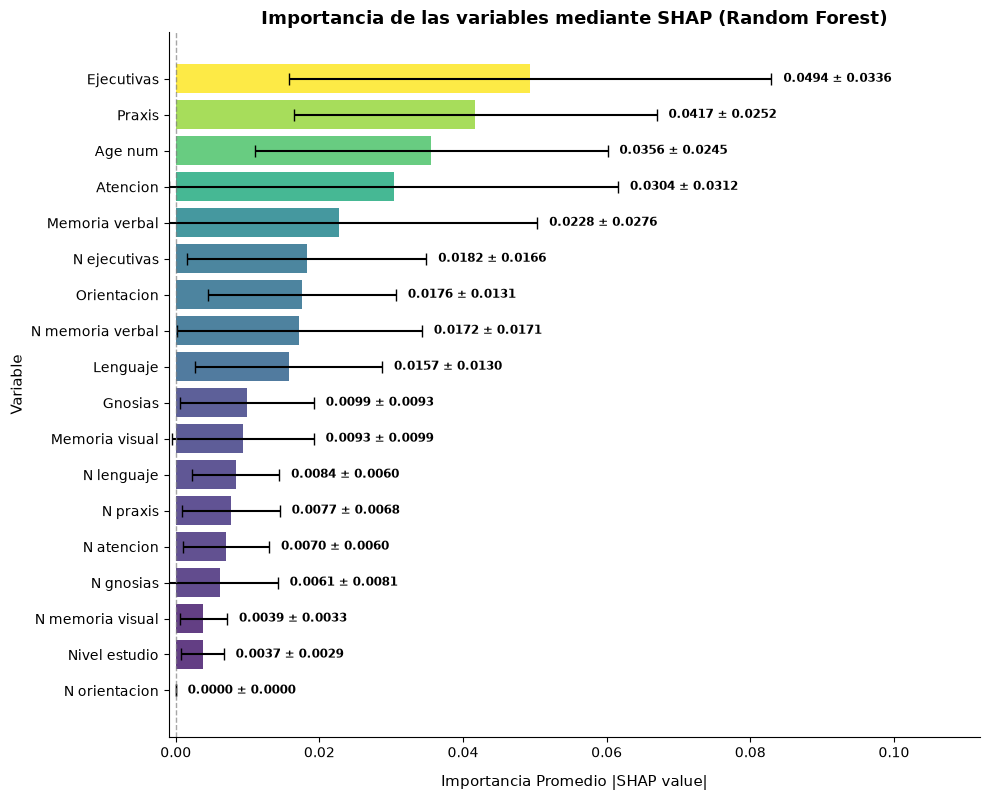

Background dataset has 117 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=117 when initializing the masker.


Calculando SHAP para Regresión Logística...


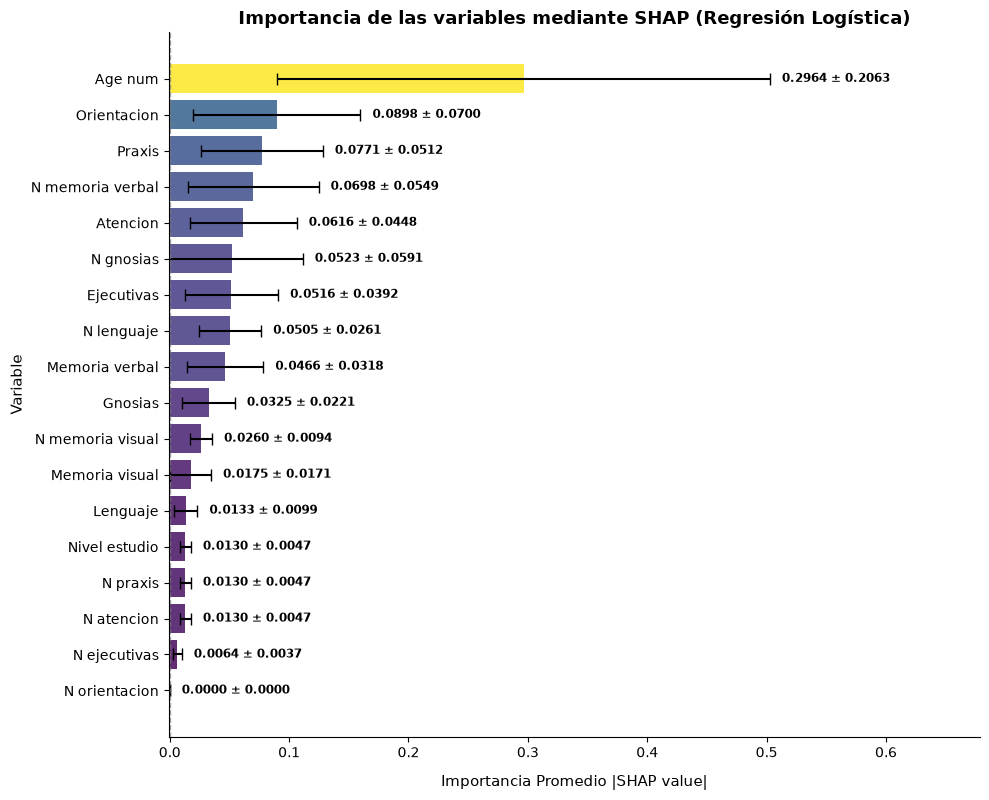

Calculando SHAP para SVM Lineal...


100%|██████████| 117/117 [00:35<00:00,  3.30it/s]


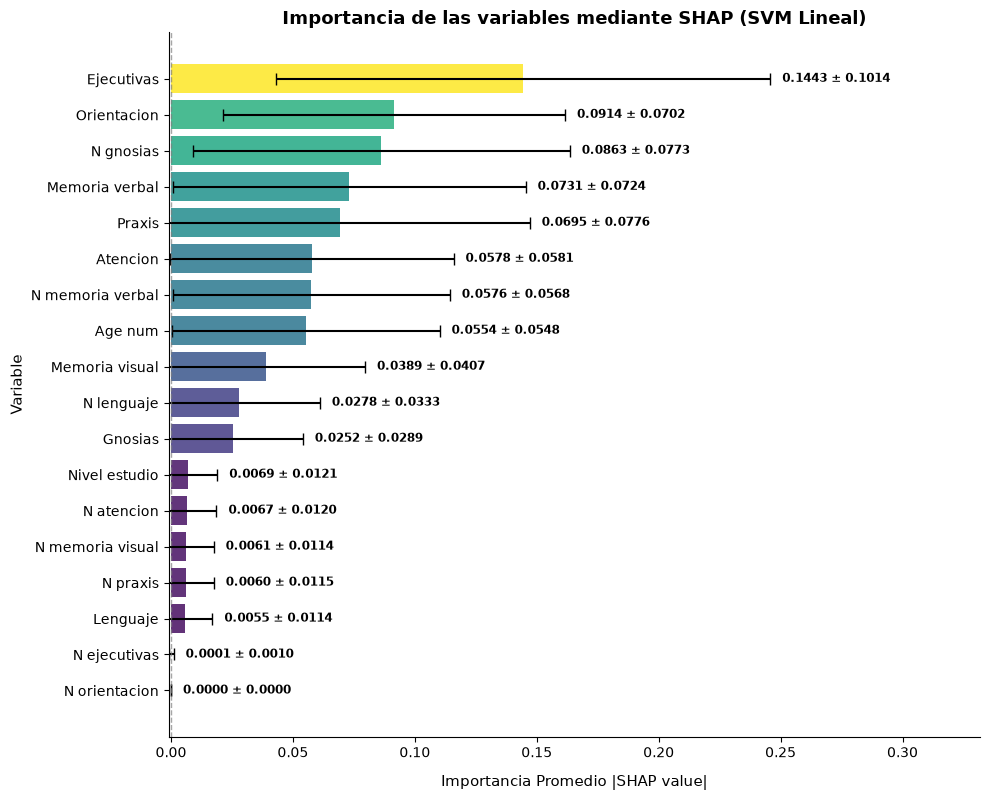

Calculando SHAP para SVM RBF...


100%|██████████| 117/117 [01:10<00:00,  1.66it/s]


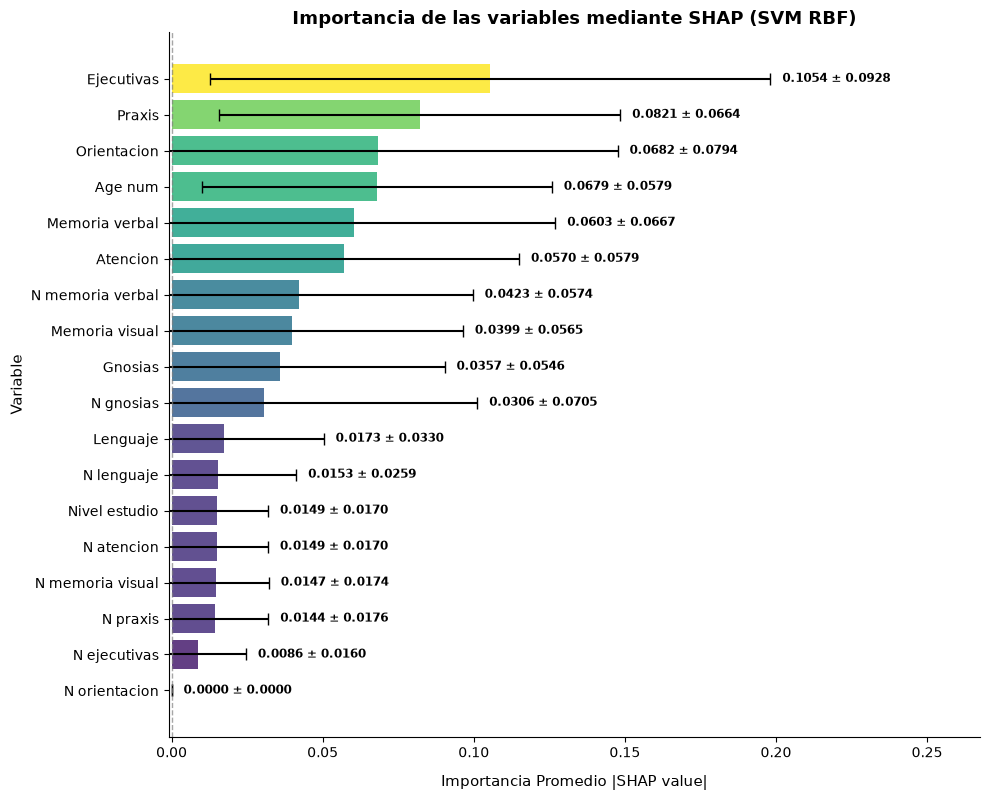

In [10]:
# 1. Random Forest
df_rf, fig = shap_importance_models(models['Random Forest'], X_mean, model_name="Random Forest")

# 2. Regresión Logística
df_lr, fig = shap_importance_models(models['Logistic Regression'], X_mean, model_name="Regresión Logística")

# 3. SVM Lineal
df_svml, fig = shap_importance_models(models['SVM Lineal'], X_mean, model_name="SVM Lineal")

# 4. SVM RBF
df_svmrbf, fig = shap_importance_models(models['SVM RBF'], X_mean, model_name="SVM RBF")

# Interpretaciones individuales

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier

def explicar_clasificación_individual(model, X, idx_individuo=0, model_name="Modelo", clase_idx=1):
    """
    explicacion individual SHAP compatible con Pipelines, Random Forest, 
    Regresión Logística, SVM (RBF / Lineal) y problemas multiclase (0, 1, 2...).
    
    Todas las explicaciones de modelos probabilísticos se devuelven 
    en la escala directa de PROBABILIDAD (0 a 1).
    """
    nombres_cols = [col.replace('_', ' ').capitalize() for col in X.columns]
    individuo_orig = X.iloc[idx_individuo]

    # Estimador final del pipeline
    if hasattr(model, 'steps'):
        estimator = model.steps[-1][1]
        X_prep = model.steps[0][1].transform(X) if len(model.steps) > 1 else X
    else:
        estimator = model
        X_prep = X

    X_prep_df = pd.DataFrame(X_prep, columns=nombres_cols) if isinstance(X_prep, np.ndarray) else X_prep

    print(f"Calculando explicacion individual para individuo #{idx_individuo} ({model_name}) | Clase {clase_idx}...")

    # RANDOM FOREST (TreeExplainer - Rápido y exacto en probabilidades)
    if isinstance(estimator, RandomForestClassifier):
        explainer = shap.TreeExplainer(estimator)
        shap_values = explainer(X_prep_df)
        
        # Manejo de arreglos 3D para multiclase
        if len(shap_values.shape) == 3:
            exp_individuo = shap_values[idx_individuo, :, clase_idx]
        else:
            exp_individuo = shap_values[idx_individuo]

    # MODELOS CON PROBABILIDAD (Regresión Logística, SVM RBF)
    elif hasattr(model, "predict_proba"):
        # Wrapper que evalúa la probabilidad exacta de la clase especificada
        def fn_prob(x):
            df_x = pd.DataFrame(x, columns=X.columns)
            return model.predict_proba(df_x)[:, clase_idx]

        background = shap.sample(X, min(50, len(X)), random_state=42)
        explainer = shap.KernelExplainer(fn_prob, background)
        
        # Evaluar paciente con los datos originales
        sv = explainer.shap_values(X.iloc[[idx_individuo]], nsamples=100)
        
        vals_1d = sv[0] if isinstance(sv, list) else sv
        base_val = explainer.expected_value

        exp_individuo = shap.Explanation(
            values=np.array(vals_1d, dtype=float).ravel(),
            base_values=float(base_val if np.isscalar(base_val) else base_val[0]),
            data=individuo_orig.values,
            feature_names=nombres_cols
        )

    # MODELOS SIN PROBABILIDAD
    else:
        def fn_decision(x):
            df_x = pd.DataFrame(x, columns=X.columns)
            res = model.decision_function(df_x)
            if res.ndim > 1:
                return res[:, clase_idx]
            return res

        background = shap.sample(X, min(50, len(X)), random_state=42)
        explainer = shap.KernelExplainer(fn_decision, background)
        
        sv = explainer.shap_values(X.iloc[[idx_individuo]], nsamples=100)
        vals_1d = sv[0] if isinstance(sv, list) else sv
        base_val = explainer.expected_value

        exp_individuo = shap.Explanation(
            values=np.array(vals_1d, dtype=float).ravel(),
            base_values=float(base_val if np.isscalar(base_val) else base_val[0]),
            data=individuo_orig.values,
            feature_names=nombres_cols
        )

    # Asignación de etiquetas 
    exp_individuo.data = individuo_orig.values
    exp_individuo.feature_names = nombres_cols

    # Graficar
    plt.close('all')
    fig = plt.figure(figsize=(9, 6), dpi=100)
    shap.plots.waterfall(exp_individuo, show=False)
    plt.title(f'explicacion Individual - Individuo #{idx_individuo} ({model_name}) | Clase {clase_idx}', fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

In [41]:
df_mean.iloc[id_individuo]['dc']

np.float64(1.0)

Calculando explicación individual para individuo #17 (Random Forest) | Clase 1...


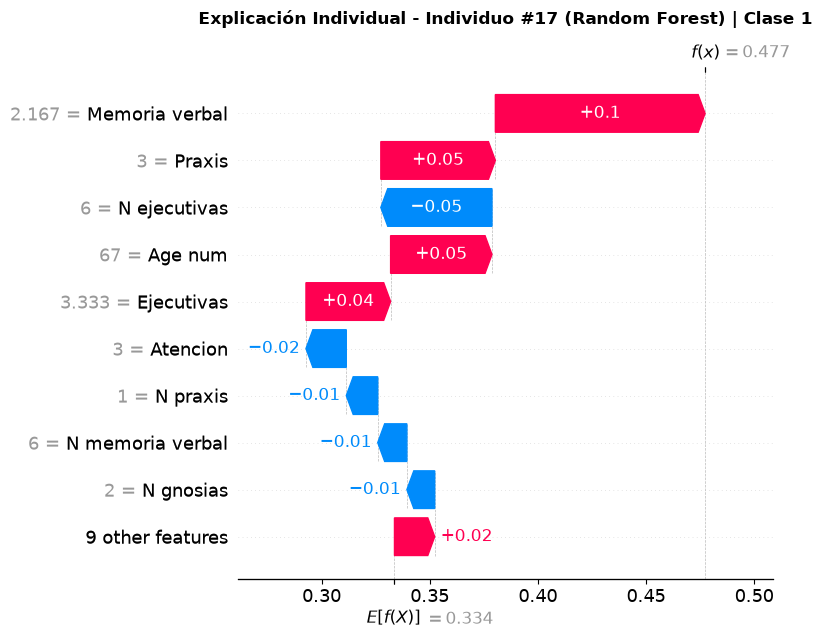

Calculando explicación individual para individuo #17 (Regresión Logística) | Clase 0...


100%|██████████| 1/1 [00:00<00:00, 40.02it/s]


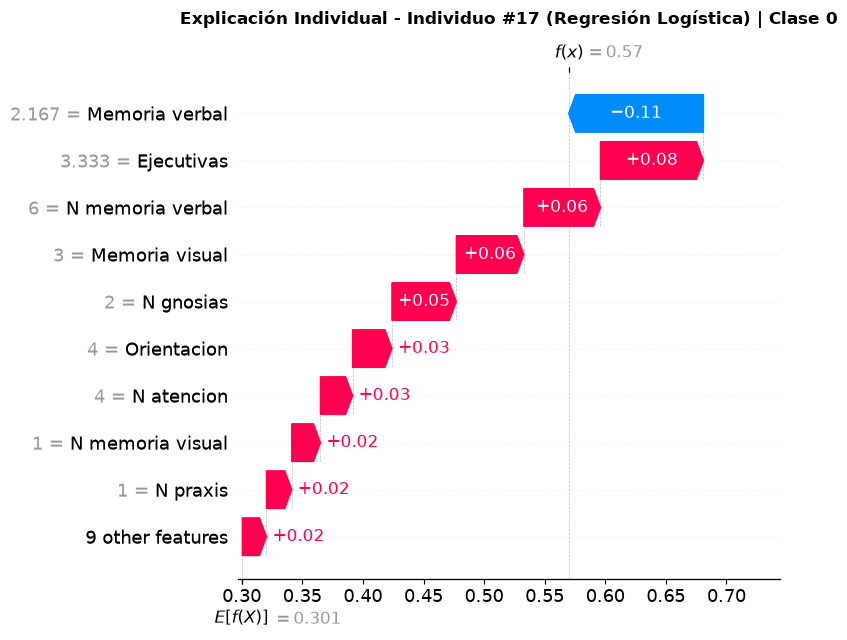

Calculando explicación individual para individuo #17 (SVM RBF) | Clase 1...


100%|██████████| 1/1 [00:00<00:00, 14.59it/s]


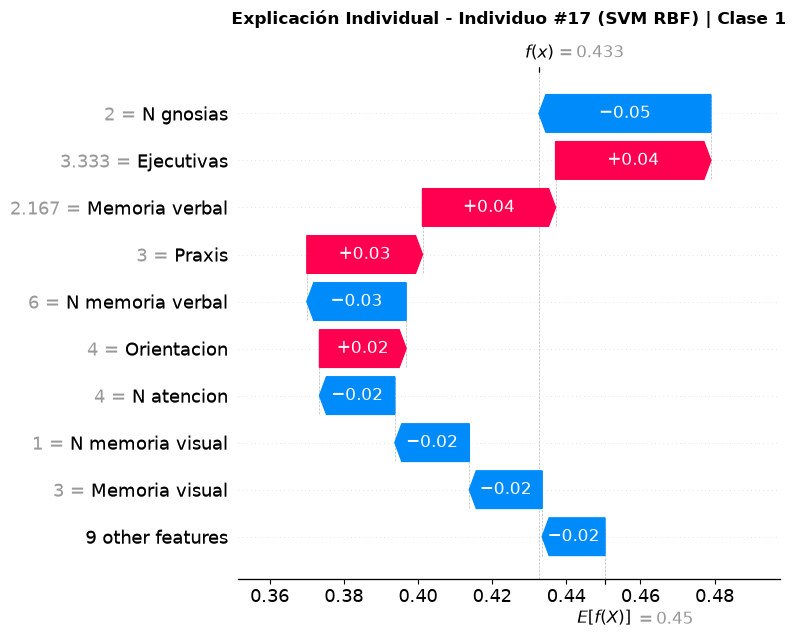

Calculando explicación individual para individuo #17 (SVM LINEAL) | Clase 1...


100%|██████████| 1/1 [00:00<00:00, 11.62it/s]


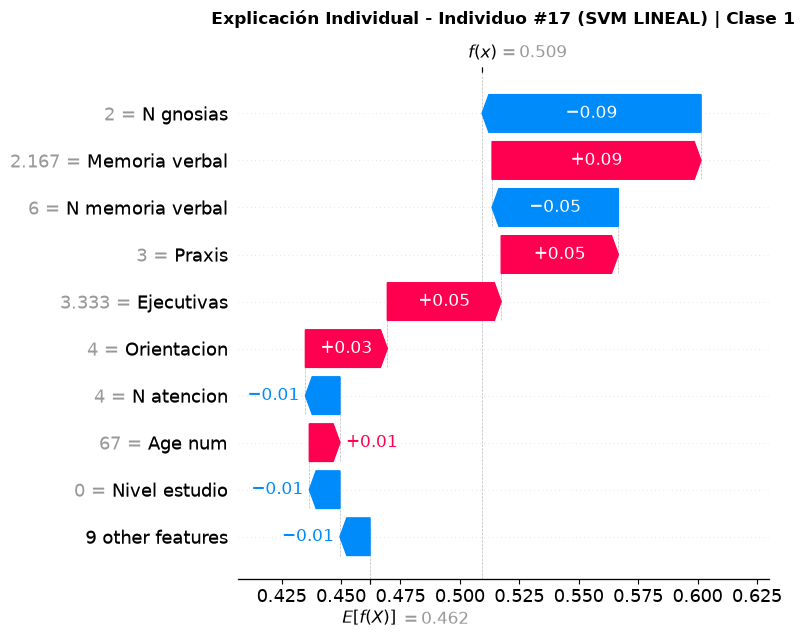

In [56]:
id_individuo = 17

explicar_clasificación_individual(models['Random Forest'], X_mean, idx_individuo=id_individuo, model_name="Random Forest")

explicar_clasificación_individual(models['Logistic Regression'], X_mean, idx_individuo=id_individuo, model_name="Regresión Logística", clase_idx=0)

explicar_clasificación_individual(models['SVM RBF'], X_mean, idx_individuo=id_individuo, model_name="SVM RBF")

explicar_clasificación_individual(models['SVM Lineal'], X_mean, idx_individuo=id_individuo, model_name="SVM LINEAL")


In [53]:
# 1. Ver la clase final asignada por la Regresión Logística
clase_ganadora = models['Logistic Regression'].predict(X_mean.iloc[[17]])[0]
print(f"La Regresión Logística clasificó al Registro #17 en la: Clase {clase_ganadora}")

# 2. Ver el desglose exacto de probabilidades para las 3 clases
probabilidades = models['Logistic Regression'].predict_proba(X_mean.iloc[[17]])[0]

print(f"Probabilidad Clase 0: {probabilidades[0]:.1%}")
print(f"Probabilidad Clase 1: {probabilidades[1]:.1%}")
print(f"Probabilidad Clase 2: {probabilidades[2]:.1%}")

La Regresión Logística clasificó al Registro #17 en la: Clase 0
Probabilidad Clase 0: 57.0%
Probabilidad Clase 1: 34.4%
Probabilidad Clase 2: 8.6%
